In [18]:
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 200)

# 1- Load Libraries

In [5]:
suppressPackageStartupMessages({
  library(tidyverse)
  library(tidymodels)
  library(readxl)
  library(janitor)
  library(plotly)
  library(corrr)
  library(sjPlot)
  library(GGally)
  library(ggpubr)
  library(patchwork)
  library(agricolae)
  library(lmerTest)
  library(openxlsx)
})

# 2- Load data

In [8]:
cleaned_data_imputed <- readRDS("data/cleaned_data_imputed.rds")

In [9]:
pgr_trt_name = c("No_PGR", "M62.5_21-24", "M62.5_30-32", "M125_30-32", "M62.5_37",
                 "M125_37", "M62.5_21-24 + M62.5_37", "M62.5_21-24 + M62.5_30-32",
                 "M62.5_30-32 + M62.5_37")
cultivation_cost_dollar = c(402.2, 411.7, 421.2, 430.7, 411.7,
                            421.2, 421.2, 430.7, 430.7)
econonmic_data <- data.frame(pgr_trt_name, cultivation_cost_dollar)

# 3- Integration of PGR Treatment Economics and Agronomic Response Metrics

In [12]:
data_int <- cleaned_data_imputed %>% 
  left_join(econonmic_data, by = "pgr_trt_name") %>% 
  mutate(gross_return = yield_bu_acre * 5.85,
         net_return = gross_return - cultivation_cost_dollar) %>% 
  mutate(PGR_dose = case_when(
    pgr_trt_name == "No_PGR" ~ 0,
    pgr_trt_name %in% c("M62.5_21-24", "M62.5_30-32", "M62.5_37") ~ 62.5,
    .default = 125
  ),
  PGR_growth_stage = case_when(
     pgr_trt_name == "No_PGR" ~ "Control",
     pgr_trt_name == "M62.5_21-24" ~ "GS 21-24 (ET)",
     pgr_trt_name %in% c("M62.5_30-32", "M125_30-32") ~ "GS 30-32 (SE)",
     pgr_trt_name %in% c("M62.5_37", "M125_37") ~ "GS 37 (FLE)",
     pgr_trt_name == "M62.5_21-24 + M62.5_37" ~ "GS 21-24 (ET) + GS 37 (FLE)",
     pgr_trt_name == "M62.5_21-24 + M62.5_30-32" ~ "GS 21-24 (ET) + GS 30-32 (SE)",
     pgr_trt_name == "M62.5_30-32 + M62.5_37" ~ "GS 30-32 (SE) + GS 37 (FLE)"
  )
  )
head(data_int)

year,location,cultivar,pgr_trt_name,yield_bu_acre,lodging_index_3,protein_percent_dm,avg_height_at_phys_maturity,tkw,test_weight_kg_h_l,⋯,starch_percent_dm,lodging_avg,lodging_index_1,lodging_index_2,yield_adj_to_13_5_percent,cultivation_cost_dollar,gross_return,net_return,PGR_dose,PGR_growth_stage
<dbl>,<fct>,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2022,Vermilion,CDC_Austenson,No_PGR,135.5724,3.333333,12.35137,72.33333,46.84555,66.13,⋯,61.80709,2.222222,0,3.333333,7292.860,402.2,793.0985,390.8985,0.0,Control
2022,Vermilion,CDC_Austenson,M62.5_21-24,127.2140,0.000000,12.16454,74.00000,45.59578,65.01,⋯,61.71610,0.000000,0,0.000000,6843.238,411.7,744.2021,332.5021,62.5,GS 21-24 (ET)
2022,Vermilion,CDC_Austenson,M62.5_30-32,117.1409,0.000000,11.94270,69.66667,49.55971,69.78,⋯,60.99495,0.000000,0,0.000000,6301.371,421.2,685.2741,264.0741,62.5,GS 30-32 (SE)
2022,Vermilion,CDC_Austenson,M62.5_37,175.9922,0.000000,11.90405,71.66667,46.57075,65.25,⋯,61.71217,0.000000,0,0.000000,9467.169,411.7,1029.5546,617.8546,62.5,GS 37 (FLE)
2022,Vermilion,CDC_Austenson,M125_30-32,138.3530,0.000000,12.28261,71.00000,48.57156,66.56,⋯,61.19565,0.000000,0,0.000000,7442.436,430.7,809.3649,378.6649,125.0,GS 30-32 (SE)
2022,Vermilion,CDC_Austenson,M125_37,156.1708,0.000000,12.39285,76.66667,46.64879,67.16,⋯,60.91529,0.000000,0,0.000000,8400.912,421.2,913.5992,492.3992,125.0,GS 37 (FLE)


# 4- Linear modeling

In [13]:
lm_env <- lm(
  yield_bu_acre ~ location * year,
  data = data_int %>%
    mutate(
      location = factor(location),
      year = factor(year)
    )
)

anova(lm_env)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
location,2,1559432.00,779716.0018,3107.63027,0.000000e+00
year,2,103301.34,51650.6687,205.85852,1.012081e-73
location:year,3,50624.91,16874.9713,67.25676,4.679410e-39
Residuals,856,214773.59,250.9037,NA,NA


# 5- Mixed modeling

## 5.1-  Yield Bu/ac

In [15]:
# Set a random seed for reproducibility
set.seed(123)

# Fit the mixed model with year & location as random effects
reg_mod_int_yield_buacre <- lmer(yield_bu_acre ~ cultivar * PGR_dose + PGR_growth_stage +
                (1 | year) + (1 | location), 
                data = data_int %>% mutate(pgr_trt_name = fct_relevel(pgr_trt_name, "No_PGR"),
                                       cultivar = fct_relevel(cultivar, "CDC_Austenson")))

# Extract fixed effects with p-values
fixed_effects <- broom.mixed::tidy(reg_mod_int_yield_buacre, effects = "fixed") %>%
  filter(term != "(Intercept)")

# Extract confidence intervals for fixed effects
conf_int <- confint(reg_mod_int_yield_buacre, method = "Wald") %>%  # Compute 95% CIs
  as.data.frame() %>%
  rownames_to_column("term") %>%
  filter(term %in% fixed_effects$term) %>%
  rename(ci_lower = `2.5 %`, ci_upper = `97.5 %`)

# Merge CIs with fixed effects
fixed_effects <- fixed_effects %>%
  left_join(conf_int, by = "term") %>%
  mutate(
    p_signif = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      p.value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

# Extract random effects (variance components) - No p-values here
random_effects <- broom.mixed::tidy(reg_mod_int_yield_buacre, effects = "ran_pars") %>%
  select(-term) %>% 
  rename(term = group) %>% 
  mutate(
    term = str_replace(term, "sd__", ""),  # Clean term names
    effect = "Random",
    p_signif = "",  # No p-values for random effects
    ci_lower = NA,  # No CIs for random effects
    ci_upper = NA
  )

# Combine fixed and random effects
model_results <- bind_rows(fixed_effects, random_effects)

# Assign grouping categories
model_results <- model_results %>%
  filter(term != "Residual") %>%
  mutate(category = case_when(
    grepl("location", term) ~ "Random Factors",
    grepl("year", term) ~ "Random Factors",
    term %in% c("cultivarAB_Hague", "cultivarEsma") ~ "Cultivar",
    term == "PGR_dose" ~ "PGR Dose",
    term %in% c("cultivarAB_Hague:PGR_dose", "cultivarEsma:PGR_dose", "cultivarCDC_Austenson:PGR_dose") ~ "Cultivar x PGR Dose",
    grepl("PGR_growth_stage", term) ~ "PGR Application Stage",
    TRUE ~ "Other"
  )) %>% 
  mutate(category = fct_relevel(category, "Random Factors"),  # Convert to factor for correct order
         significant_or_not = case_when(p.value < 0.05 ~ "Significant",
                                        p.value >= 0.05 ~ "Not Significant",
                                        .default = "other"
           
         )) %>% 
  mutate(term = case_when(
    term == "cultivarAB_Hague" ~ "AB Hague",
     term == "cultivarEsma" ~ "Esma",
    term == "PGR_dose" ~ "PGR Rate",
    term == "cultivarAB_Hague:PGR_dose" ~ "AB Hague x PGR Dose",
    term == "cultivarEsma:PGR_dose" ~ "Esma x PGR Dose",
    term == "cultivarCDC_Austenson:PGR_dose" ~ "CDC Austenson x PGR Dose",
    term == "PGR_growth_stageGS 21-24 (ET)" ~ "GS 21-24 (ET)",
    term == "PGR_growth_stageGS 21-24 (ET) + GS 37 (FLE)" ~ "GS 21-24 (ET) + GS 37 (FLE)",
    term == "PGR_growth_stageGS 21-24 (ET) + GS 30-32 (SE)" ~ "GS 21-24 (ET) + GS 30-32 (SE)",
    term == "PGR_growth_stageGS 37 (FLE)" ~ "GS 37 (FLE)",
    term == "PGR_growth_stageGS 30-32 (SE)" ~ "GS 30-32 (SE)",
    term == "PGR_growth_stageGS 30-32 (SE) + GS 37 (FLE)" ~ "GS 30-32 (SE) + GS 37 (FLE)",
    TRUE ~ term
  )) 

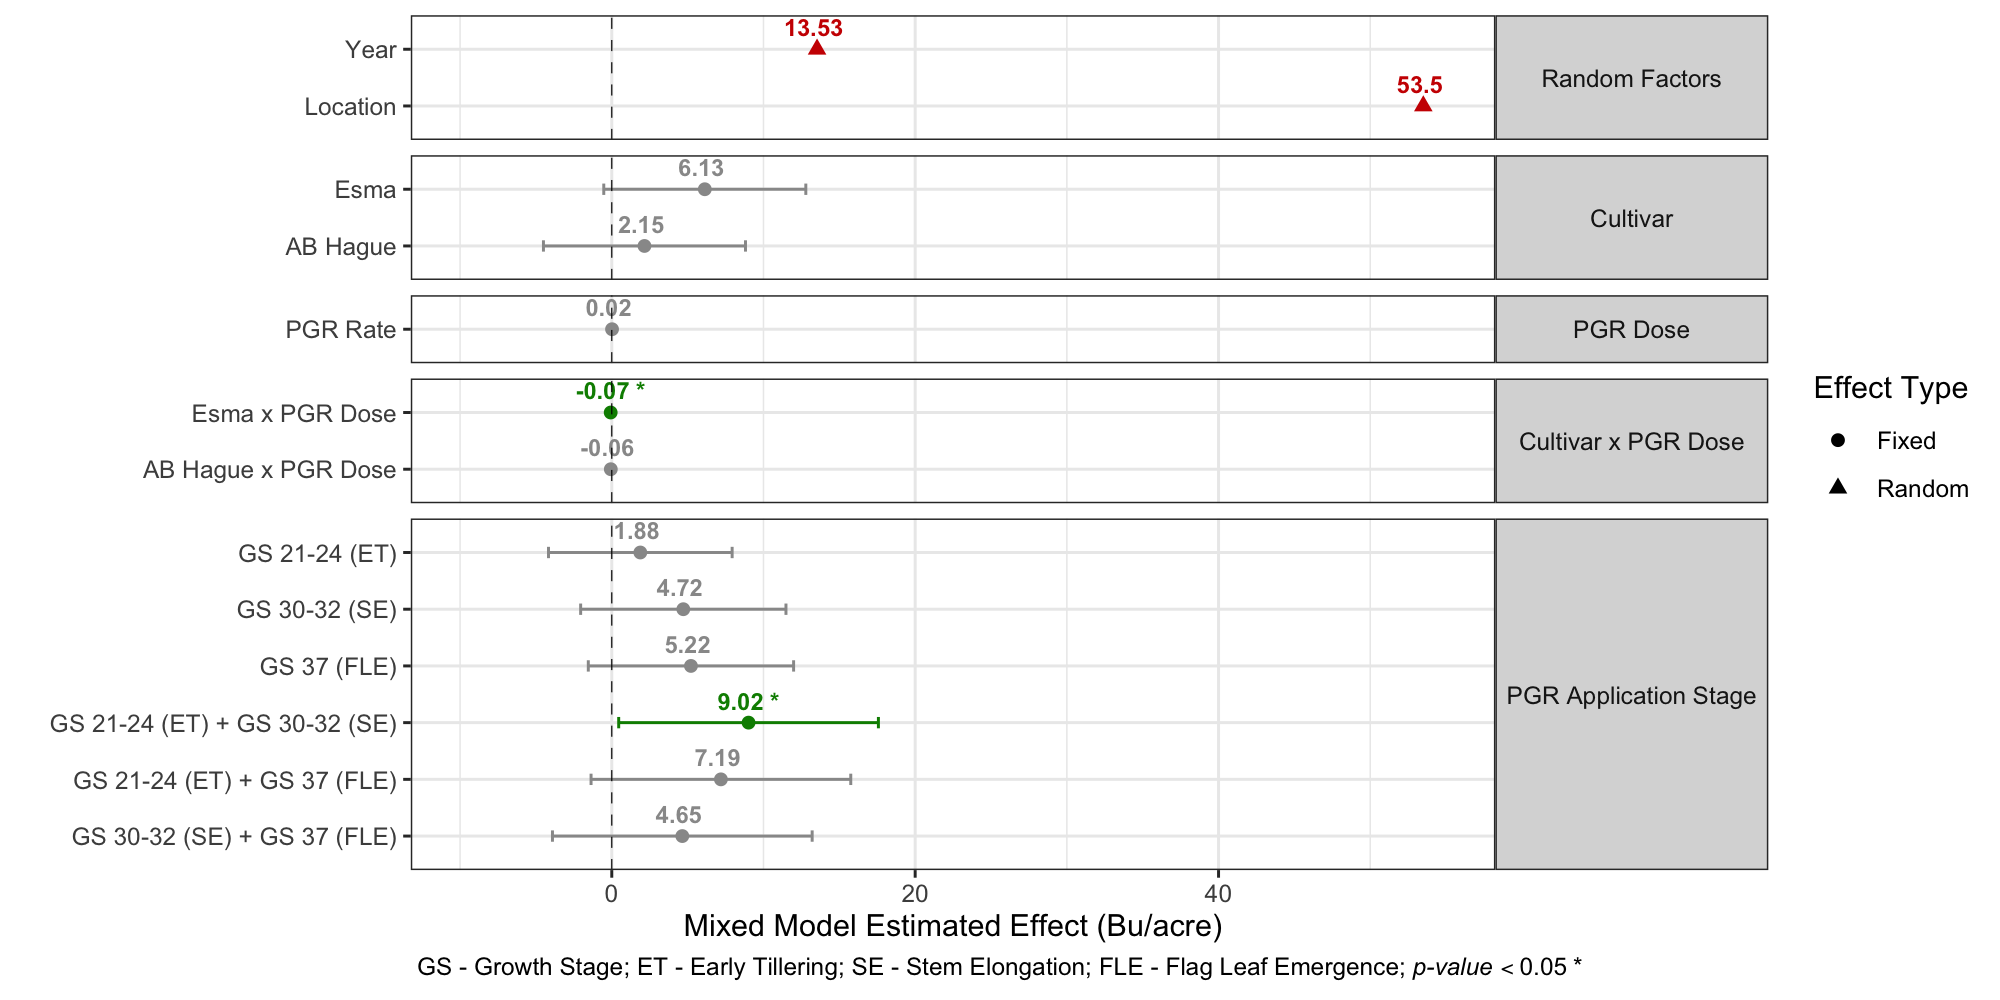

In [20]:

# Apply manual order to the "term" column for PGR treatments only
#model_results <- model_results %>%
# Plot with significance stars and confidence intervals
# Define custom order for PGR treatments
custom_order_2 <- c("Random Factors", 
                  "Year", 
                  "Cultivar",
                  "PGR Dose",
                  "Cultivar x PGR Dose",
                  "PGR Application Stage")

custom_order_3 <- c("GS 30-32 (SE) + GS 37 (FLE)",
                    "GS 21-24 (ET) + GS 37 (FLE)",
                     "GS 21-24 (ET) + GS 30-32 (SE)",
                     "GS 37 (FLE)",
                     "GS 30-32 (SE)", 
                    "GS 21-24 (ET)"
                  )

model_results <- model_results %>%
  mutate(
    effect = recode(effect, "fixed" = "Fixed"),
    
    term = recode(term,
                  "year" = "Year",
                  "location" = "Location"),
    
    # Relevel only existing category levels (prevents "unknown level" warning)
    category = forcats::fct_relevel(
      category,
      intersect(custom_order_2, levels(factor(category)))
    ),
    
    # Reorder term levels safely
    term = forcats::fct_relevel(term, custom_order_3)
  )


ggplot(model_results,
       aes(x = estimate, y = term, shape = effect, color = significant_or_not)) +
  
  geom_point(size = 2) +
  
  # Use width instead of height (prevents translation message)
  geom_errorbarh(aes(xmin = ci_lower, xmax = ci_upper), width = 0.2) +
  
  geom_text(
    aes(label = paste(round(estimate, 2), p_signif)),
    hjust = 0.5, vjust = -0.8, size = 3, fontface = "bold",
    show.legend = FALSE
  ) +
  facet_grid(category ~ ., scales = "free_y", space = "free_y") +
  
  geom_vline(xintercept = 0, lwd = 0.2, linetype = "dashed") +
  
  scale_shape_manual(values = c(16, 17)) +
  scale_color_manual(values = c("gray60", "red3", "green4")) +
  
  labs(
    x = "Mixed Model Estimated Effect (Bu/acre)",
    y = "",
    caption = expression("GS - Growth Stage; ET - Early Tillering; SE - Stem Elongation; FLE - Flag Leaf Emergence; " *
                           italic("p-value") < 0.05 ~ "*"),
    shape = "Effect Type",
    color = "P-Value"
  ) +
  
  coord_cartesian(xlim = c(-10, 55)) +
  
  theme_bw() +
  guides(color = "none") +
  
  theme(
    strip.text.y = element_text(angle = 0),
    plot.caption.position = "plot",
    plot.caption = element_text(hjust = 0.5)
  )

ggsave("figure/Yield_mixed_modeling_yield_bu_ac.png", width = 8, height = 5, dpi = 600)

## 5.1-  Yield kg/ha

In [22]:
# Set a random seed for reproducibility
set.seed(123)

# Fit the mixed model with year & location as random effects
reg_mod_int_yield_kgha <- lmer(yield_adj_to_13_5_percent ~ cultivar * PGR_dose + PGR_growth_stage +
                (1 | year) + (1 | location), 
                data = data_int %>% mutate(pgr_trt_name = fct_relevel(pgr_trt_name, "No_PGR"),
                                       cultivar = fct_relevel(cultivar, "CDC_Austenson")))

# Extract fixed effects with p-values
fixed_effects <- broom.mixed::tidy(reg_mod_int_yield_kgha, effects = "fixed") %>%
  filter(term != "(Intercept)")

# Extract confidence intervals for fixed effects
conf_int <- confint(reg_mod_int_yield_kgha, method = "Wald") %>%  # Compute 95% CIs
  as.data.frame() %>%
  rownames_to_column("term") %>%
  filter(term %in% fixed_effects$term) %>%
  rename(ci_lower = `2.5 %`, ci_upper = `97.5 %`)

# Merge CIs with fixed effects
fixed_effects <- fixed_effects %>%
  left_join(conf_int, by = "term") %>%
  mutate(
    p_signif = case_when(
      p.value < 0.001 ~ "***",
      p.value < 0.01  ~ "**",
      p.value < 0.05  ~ "*",
      TRUE ~ ""
    )
  )

# Extract random effects (variance components) - No p-values here
random_effects <- broom.mixed::tidy(reg_mod_int_yield_kgha, effects = "ran_pars") %>%
  select(-term) %>% 
  rename(term = group) %>% 
  mutate(
    term = str_replace(term, "sd__", ""),  # Clean term names
    effect = "Random",
    p_signif = "",  # No p-values for random effects
    ci_lower = NA,  # No CIs for random effects
    ci_upper = NA
  )

# Combine fixed and random effects
model_results <- bind_rows(fixed_effects, random_effects)

# Assign grouping categories
model_results <- model_results %>%
  filter(term != "Residual") %>%
  mutate(category = case_when(
    grepl("location", term) ~ "Random Factors",
    grepl("year", term) ~ "Random Factors",
    term %in% c("cultivarAB_Hague", "cultivarEsma") ~ "Cultivar",
    term == "PGR_dose" ~ "PGR Dose",
    term %in% c("cultivarAB_Hague:PGR_dose", "cultivarEsma:PGR_dose", "cultivarCDC_Austenson:PGR_dose") ~ "Cultivar x PGR Dose",
    grepl("PGR_growth_stage", term) ~ "PGR Application Stage",
    TRUE ~ "Other"
  )) %>% 
  mutate(category = fct_relevel(category, "Random Factors"),  # Convert to factor for correct order
         significant_or_not = case_when(p.value < 0.05 ~ "Significant",
                                        p.value >= 0.05 ~ "Not Significant",
                                        .default = "other"
           
         )) %>% 
  mutate(term = case_when(
    term == "cultivarAB_Hague" ~ "AB Hague",
     term == "cultivarEsma" ~ "Esma",
    term == "PGR_dose" ~ "PGR Rate",
    term == "cultivarAB_Hague:PGR_dose" ~ "AB Hague x PGR Dose",
    term == "cultivarEsma:PGR_dose" ~ "Esma x PGR Dose",
    term == "cultivarCDC_Austenson:PGR_dose" ~ "CDC Austenson x PGR Dose",
    term == "PGR_growth_stageGS 21-24 (ET)" ~ "GS 21-24 (ET)",
    term == "PGR_growth_stageGS 21-24 (ET) + GS 37 (FLE)" ~ "GS 21-24 (ET) + GS 37 (FLE)",
    term == "PGR_growth_stageGS 21-24 (ET) + GS 30-32 (SE)" ~ "GS 21-24 (ET) + GS 30-32 (SE)",
    term == "PGR_growth_stageGS 37 (FLE)" ~ "GS 37 (FLE)",
    term == "PGR_growth_stageGS 30-32 (SE)" ~ "GS 30-32 (SE)",
    term == "PGR_growth_stageGS 30-32 (SE) + GS 37 (FLE)" ~ "GS 30-32 (SE) + GS 37 (FLE)",
    TRUE ~ term
  )) 

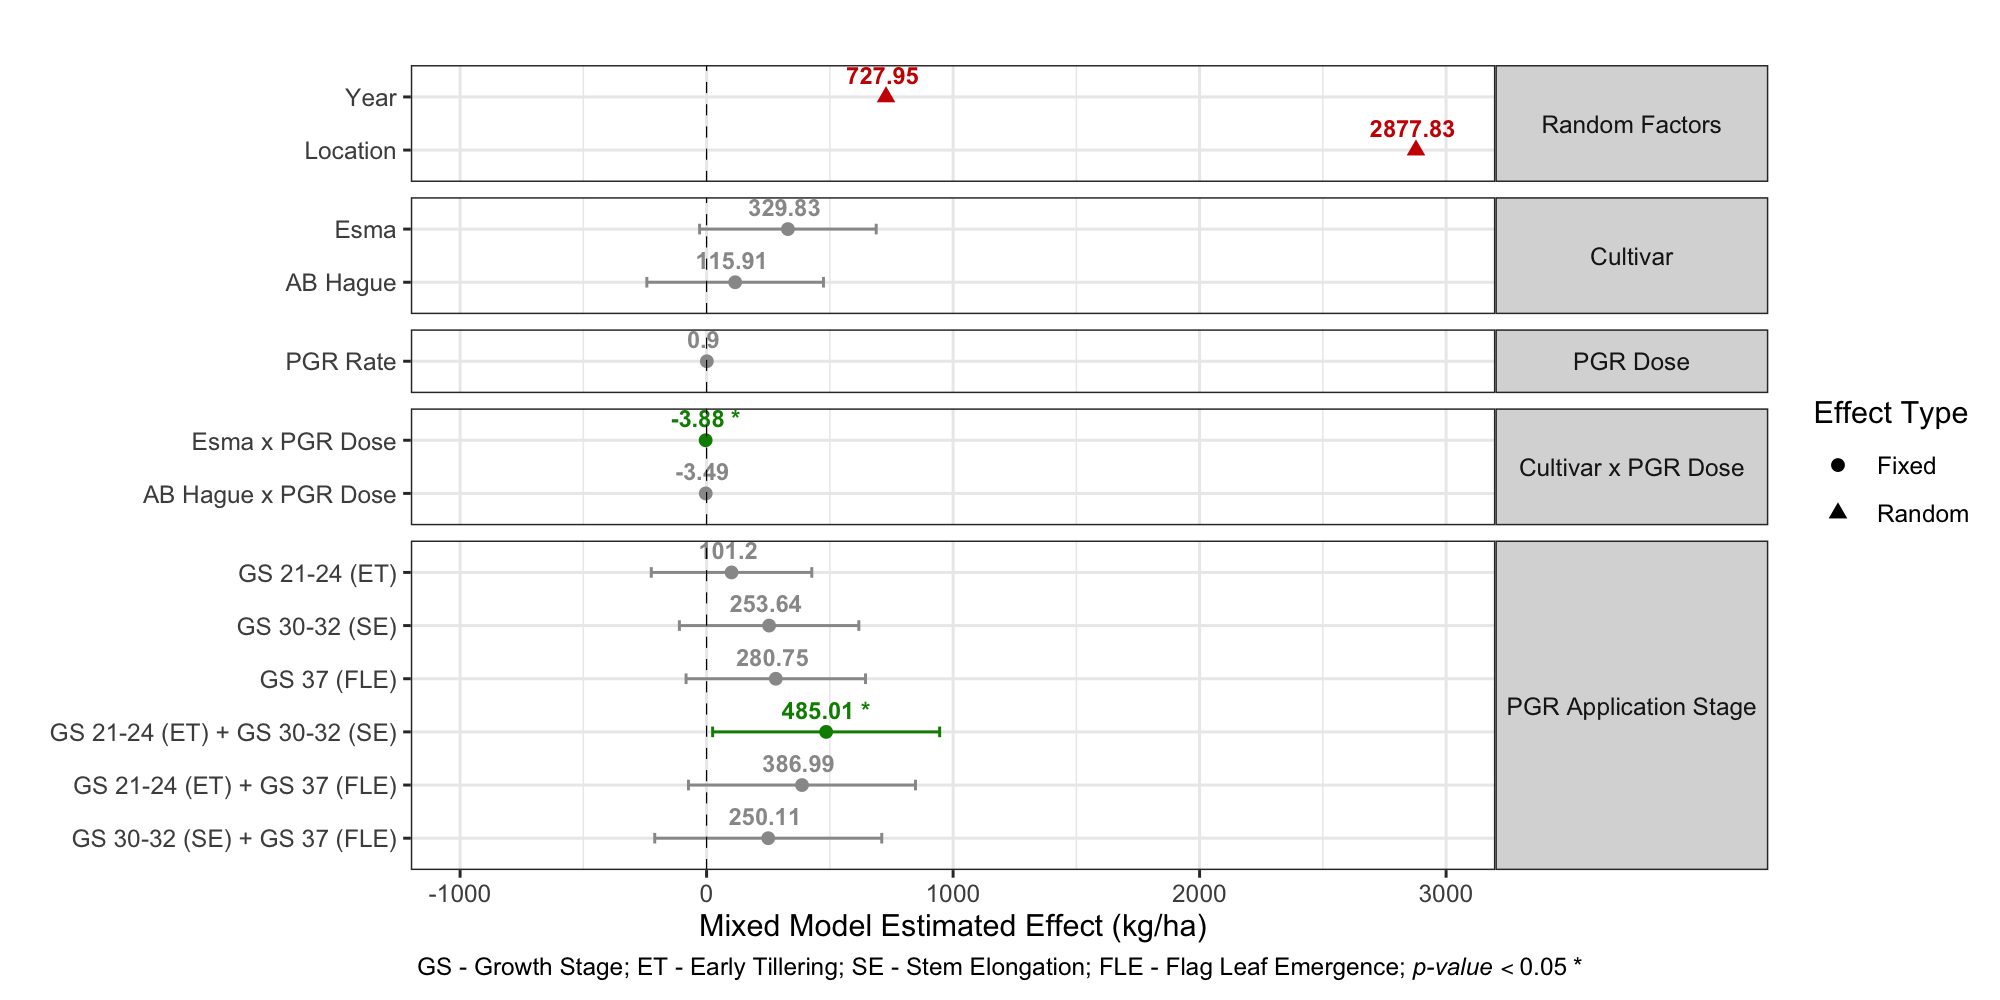

In [24]:
custom_order_2 <- c("Random Factors","Year","Cultivar","PGR Dose","Cultivar x PGR Dose","PGR Application Stage")
custom_order_3 <- c("GS 30-32 (SE) + GS 37 (FLE)","GS 21-24 (ET) + GS 37 (FLE)","GS 21-24 (ET) + GS 30-32 (SE)",
                    "GS 37 (FLE)","GS 30-32 (SE)","GS 21-24 (ET)")

model_results <- model_results %>%
  mutate(
    effect = recode(effect, "fixed" = "Fixed"),
    term   = recode(term, "year" = "Year", "location" = "Location"),
    category = forcats::fct_relevel(category, intersect(custom_order_2, levels(factor(category)))),
    term     = forcats::fct_relevel(term, custom_order_3)
  )

ggplot(model_results, aes(x = estimate, y = term, shape = effect, color = significant_or_not)) +
  geom_point(size = 2) +
  geom_errorbarh(aes(xmin = ci_lower, xmax = ci_upper), width = 0.2) +
  geom_text(aes(label = paste(round(estimate, 2), p_signif)),
            hjust = 0.5, vjust = -0.8, size = 3, fontface = "bold", show.legend = FALSE) +
  facet_grid(category ~ ., scales = "free_y", space = "free_y") +
  geom_vline(xintercept = 0, lwd = 0.2, linetype = "dashed") +
  scale_shape_manual(values = c(16, 17)) +
  scale_color_manual(values = c("gray60", "red3", "green4")) +
  labs(
    title = "",
    x = "Mixed Model Estimated Effect (kg/ha)",
    y = "",
    caption = expression("GS - Growth Stage; ET - Early Tillering; SE - Stem Elongation; FLE - Flag Leaf Emergence; " *
                           italic("p-value") < 0.05 ~ "*"),
    shape = "Effect Type",
    color = "P-Value"
  ) +
  coord_cartesian(xlim = c(-1000, 3000)) +
  theme_bw() +
  guides(color = "none") +
  theme(
    strip.text.y = element_text(angle = 0),
    plot.caption.position = "plot",
    plot.caption = element_text(hjust = 0.5)
  )

ggsave("figure/Yield_mixed_modeling_yield_kg_ha.png", width = 8, height = 5, dpi = 600)